# MAM Adapter — 统一视角

配套 lecture: [../lectures/06-mam-adapter.md](../lectures/06-mam-adapter.md)

本 notebook 演示:
1. MAM = Prefix + Parallel 的组合结构
2. 数值验证: Parallel去σ ≡ LoRA
3. MAM vs Pfeiffer vs LoRA mini training

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

src = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src))

from mam_minimal import MAMGPT2, PrefixAttention
from parallel_minimal import ParallelAdapter, ParallelAdapterGPT2
from pfeiffer_minimal import PfeifferGPT2
from common import print_param_summary

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. MAM 参数构成

In [2]:
torch.manual_seed(42)
model = MAMGPT2(prefix_len=30, r=16)
print_param_summary(model, 'MAM Adapter (l=30, r=16)')

# 拆分 Prefix vs Parallel
prefix_p, parallel_p = 0, 0
for name, p in model.named_parameters():
    if not p.requires_grad: continue
    if 'P_k' in name or 'P_v' in name: prefix_p += p.numel()
    elif 'down' in name or 'up' in name: parallel_p += p.numel()

print(f'\nPrefix (P_k, P_v):  {prefix_p:,}')
print(f'Parallel (down, up): {parallel_p:,}')
print(f'Total:               {prefix_p + parallel_p:,}')


  MAM Adapter (l=30, r=16)
  Total params:       125,297,088
  Trainable params:       857,280  (0.6842%)
  Frozen params:      124,439,808

Prefix (P_k, P_v):  552,960
Parallel (down, up): 304,320
Total:               857,280


## 2. 统一视角 — 数值验证 Parallel去σ ≡ LoRA

In [3]:
# 在 small example 上：parallel(x) without σ == LoRA forward
import torch.nn as nn
d, r = 16, 4
torch.manual_seed(0)
x = torch.randn(2, 4, d)
W_down = torch.randn(r, d) * 0.1
W_up = torch.randn(d, r) * 0.1

# Parallel 去 σ:
out_parallel_no_sigma = x @ W_down.T @ W_up.T  # (b, s, d)
# LoRA: 等价于 (W_up @ W_down) x
delta_W = W_up @ W_down  # (d, d), rank=r
out_lora = x @ delta_W.T

diff = (out_parallel_no_sigma - out_lora).abs().max().item()
print(f'Parallel (no σ) vs LoRA: max|Δ| = {diff:.4e}')
print(f'→ 严格相等：Parallel(σ=identity) = LoRA')
print(f'\ndelta_W rank: {torch.linalg.matrix_rank(delta_W).item()} = r = {r}')

Parallel (no σ) vs LoRA: max|Δ| = 1.4901e-08
→ 严格相等：Parallel(σ=identity) = LoRA

delta_W rank: 4 = r = 4


## 3. MAM vs 单方法 mini training

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


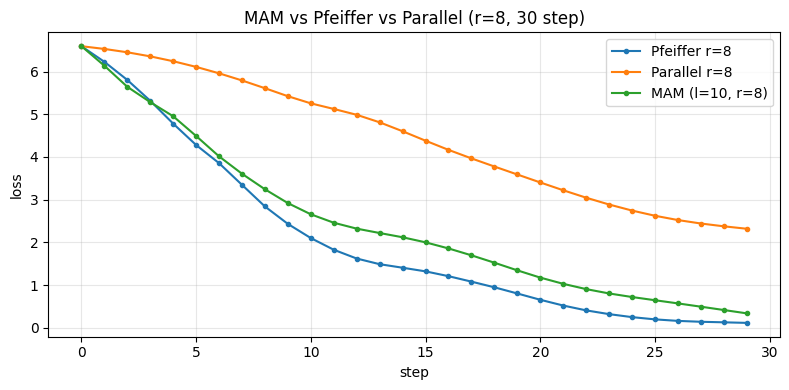

        Pfeiffer r=8 final: 0.1140
        Parallel r=8 final: 2.3186
     MAM (l=10, r=8) final: 0.3373


In [4]:
torch.manual_seed(42)
mam = MAMGPT2(prefix_len=10, r=8)  # 缩小以加速
torch.manual_seed(42)
pfe = PfeifferGPT2(r=8)
torch.manual_seed(42)
par = ParallelAdapterGPT2(r=8)

tok = mam.tokenizer
inputs = tok([
    'hello world this is a test',
    'i love this amazing product',
    'absolutely terrible movie',
    'fantastic experience from start to finish'
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

models = [
    ('Pfeiffer r=8', pfe, torch.optim.AdamW([p for p in pfe.parameters() if p.requires_grad], lr=1e-3)),
    ('Parallel r=8', par, torch.optim.AdamW([p for p in par.parameters() if p.requires_grad], lr=1e-3)),
    ('MAM (l=10, r=8)', mam, torch.optim.AdamW([p for p in mam.parameters() if p.requires_grad], lr=1e-3)),
]

losses = {n: [] for n, _, _ in models}
for step in range(30):
    for name, m, opt in models:
        opt.zero_grad()
        out = m(**inputs)
        out.loss.backward()
        opt.step()
        losses[name].append(out.loss.item())

plt.figure(figsize=(8, 4))
for n in losses:
    plt.plot(losses[n], label=n, marker='o', markersize=3)
plt.xlabel('step'); plt.ylabel('loss')
plt.title('MAM vs Pfeiffer vs Parallel (r=8, 30 step)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
for n in losses: print(f'{n:>20} final: {losses[n][-1]:.4f}')

## 4. 思考题

1. 把 prefix_len 改为 0，参数量变化多少？此时 MAM 退化为什么？
2. 在 attention 端用 LoRA 而不是 Prefix 行不行？参数量比 MAM 大还是小？
3. He et al. 论文实验 MAM 用 6.7% 参数，比 LoRA (0.84%) 多 8 倍——是否说明 MAM 是不公平比较？

下节: **K-Adapter + MAD-X** (应用层 PEFT)